# New Gaussian Curve Fit Algorithm Testing
Tests [`gaussian_curve_fit_CLAUDE.py`](gaussian_curve_fit_CLAUDE.py).

In [5]:
%matplotlib widget

In [6]:
eso_login = "goodmanj"
from astroquery.eso import Eso
eso = Eso()
eso.login(username=eso_login)


INFO: Authenticating goodmanj on 'www.eso.org' ... [astroquery.eso.core]
INFO: Authentication successful! [astroquery.eso.core]


In [7]:
import sys
sys.path.append("..")
import optical_seti_functions
import seti_catalog_functions
import Gaussian_Injector
import csv
import random
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
eso_cache_folder = Path(eso.cache_location)
from astropy.io import fits
import gaussian_curve_fit_CLAUDE


In [9]:
# Pick 10 random targets from OSETI_targets.txt.
# Run this once to generate a list, then use the same list for all future runs.
with open("../OSETI_targets.txt") as f:
    dict_reader = csv.DictReader(f,delimiter='\t',fieldnames=["Target", "RA", "DEC", "SpType", "T_eff",	"B","V","G","Dist","Explore","products_ascii","products_csv"])
    OSETI_targets_dict = list(dict_reader)
n_rows = len(OSETI_targets_dict)
target_rows = [random.randint(0,n_rows-1) for i in range(10)]
targets = [OSETI_targets_dict[i]["Target"] for i in target_rows]
targets

['GJ526',
 'HD18754',
 'HD215625',
 'HD119288',
 'K2-138',
 'HD40808',
 'HD91988',
 'GJ9133',
 'HD146624',
 'HD162598']

In [13]:
# Use this particular list of targets every time this code is run
targets = ['HD72968',
 'HIP56489',
 'HD50060',
 'HD92588',
 'GJ3187',
 'HD95521',
 'HD218566',
 'GJ1065',
 'HIP1119',
 'HD207700']

In [ ]:
import importlib
importlib.reload(seti_catalog_functions)
importlib.reload(gaussian_curve_fit_CLAUDE)

In [14]:
# Download one observation of each star, as needed
star_files = [seti_catalog_functions.download_one_obs(target,eso) for target in targets]

using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_02_09.883.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2021-05-19T01_02_07.372.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-02T10_03_01.833.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2024-04-24T01_01_13.087.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2016-01-11T01_03_47.070.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-24T09_41_30.860.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2016-06-21T01_04_10.871.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-09-29T13_27_04.900.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2014-10-01T10_21_34.313.fits
using cached file C:\Users\goodm\.astropy\cache\astroquery\Eso\ADP.2023-05-14T01_02_03.938.fits


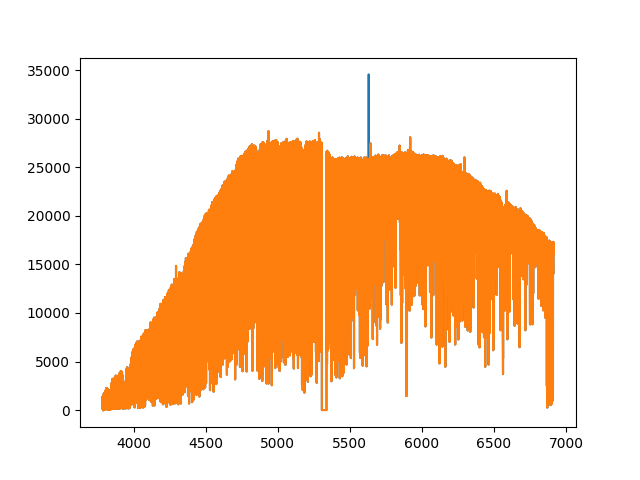

In [15]:
# Plot one of the files with an example Gaussian injected.
[wave,arr1] = optical_seti_functions.read_harps_file(star_files[9][0])
array_length = len(arr1)
center = random.randint(0,array_length)
modded_spectrum = Gaussian_Injector.add_gaussian_to_array(arr1,fwhm=10,center=float(center),array_length=array_length,area=100000)
plt.figure(1)
plt.clf()
plt.plot(wave,modded_spectrum,wave,arr1)
plt.show()

Test fit to a Gaussian and plot

In [17]:
center_wl = wave[center]
print(center_wl)
result = gaussian_curve_fit_CLAUDE.fit_gaussian_to_spike(wave, modded_spectrum, wl_min=center_wl-1,wl_max=center_wl+1)

5630.45


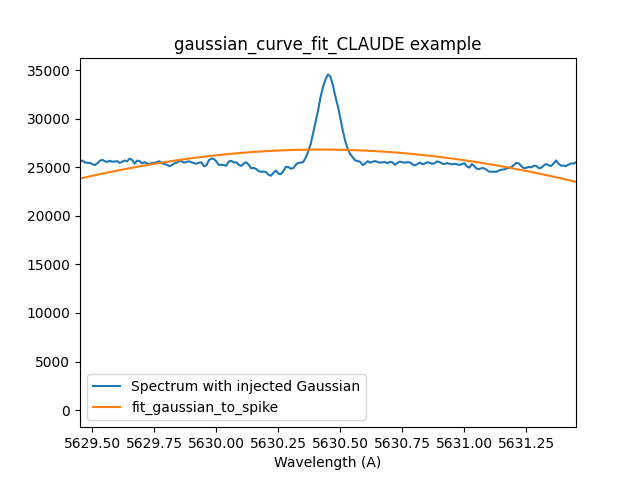

In [18]:
plt.figure(2)
plt.clf()
plt.plot(wave,modded_spectrum,result['wavelengths'],result['fitted_flux'])
plt.xlim((min(result['wavelengths']),max(result['wavelengths'])))
plt.title("gaussian_curve_fit_CLAUDE example")
plt.xlabel("Wavelength (A)")
plt.legend(["Spectrum with injected Gaussian","fit_gaussian_to_spike"])
plt.show()

Ugh!  This is frickin' terrible.  Also worth noting that this curve fitter gives error bars.  The error in FWHM is huge:

In [19]:
print(f"Amplitude error = {result['perr'][0]}")
print(f"Center error = {result['perr'][1]}")
print(f"FWHM error = {result['perr'][2]*2.3548}")

Amplitude error = 186.21497619909354
Center error = 0.03396330081016573
FWHM error = 0.30411212220810424


Let's try again, but also include a constant offset in our Gaussian fit.

In [20]:
center_wl = wave[center]
print(center_wl)
# use fit_offset_gaussian_to_spike instead
result = gaussian_curve_fit_CLAUDE.fit_offset_gaussian_to_spike(wave, modded_spectrum, wl_min=center_wl-1,wl_max=center_wl+1)

5630.45


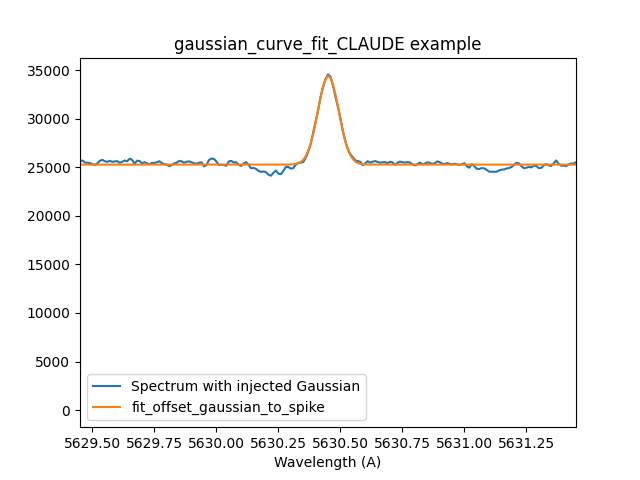

In [21]:
plt.figure(3)
plt.clf()
plt.plot(wave,modded_spectrum,result['wavelengths'],result['fitted_flux'])
plt.xlim((min(result['wavelengths']),max(result['wavelengths'])))
plt.title("gaussian_curve_fit_CLAUDE example")
plt.xlabel("Wavelength (A)")
plt.legend(["Spectrum with injected Gaussian","fit_offset_gaussian_to_spike"])
plt.show()

Sweet.  What about the errors?

In [22]:
print(f"Amplitude error = {result['perr'][0]}")
print(f"Center error = {result['perr'][1]}")
print(f"FWHM error = {result['perr'][2]*2.3548}")
print(f"offset error = {result['perr'][3]}")

Amplitude error = 150.3291218948838
Center error = 0.0007908558422062464
FWHM error = 0.0019006524561002386
offset error = 24.864537830890697


FWHM error is 300 times smaller!